# TP1 — Análisis Exploratorio de Datos y Visualización
### Laboratorio de Datos II — UNL / FICH — Ingeniería en Inteligencia Artificial

**Dataset:** [Palmer Penguins](https://github.com/allisonhorst/penguins) — mediciones morfológicas de tres
especies de pingüinos (*Adelie*, *Chinstrap*, *Gentoo*) recolectadas en islas del archipiélago Palmer (Antártida).

Este notebook resuelve los Ejercicios 1 a 4 de la guía. El Ejercicio 5 (dashboard interactivo en
Streamlit) se entrega aparte, en `dashboard.py`, ya que Streamlit no corre dentro de un notebook.

**Contenido:**
1. Estadística descriptiva y análisis univariado
2. Análisis bivariado — correlaciones y asociaciones
3. Análisis multivariado y visualización avanzada
4. Muestreo y reducción dimensional


## Configuración inicial

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import linkage, dendrogram
from pandas.plotting import scatter_matrix, parallel_coordinates
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42

datos_penguins = sns.load_dataset("penguins")
datos_penguins.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## Ejercicio 1: Estadística Descriptiva y Análisis Univariado

### 1.1 Estructura básica del dataset


In [2]:
print(f"Dimensiones (filas, columnas): {datos_penguins.shape}")
datos_penguins.info()


Dimensiones (filas, columnas): (344, 7)
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 24.9 KB


In [3]:
faltantes = datos_penguins.isnull().sum().to_frame("n_faltantes")
faltantes["pct_faltantes"] = (datos_penguins.isnull().mean() * 100).round(2)
faltantes


,n_faltantes,pct_faltantes
species,0,0.00
island,0,0.00
bill_length_mm,2,0.58
bill_depth_mm,2,0.58
flipper_length_mm,2,0.58
body_mass_g,2,0.58
sex,11,3.20


**Lectura de la estructura:** el dataset tiene 344 observaciones y 7 columnas (3 categóricas:
`species`, `island`, `sex`; 4 numéricas: `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`,
`body_mass_g`). Hay valores faltantes acotados: 2 filas con las cuatro medidas numéricas ausentes
simultáneamente (probablemente el mismo registro incompleto) y 11 filas sin dato de `sex`. Al ser
pocos casos sobre el total, se pueden excluir con `dropna()` para los análisis que lo requieran sin
perder representatividad.


In [4]:
# Vista de trabajo sin filas totalmente incompletas en las variables numericas
pinguinos = datos_penguins.dropna(subset=["bill_length_mm", "bill_depth_mm",
                                           "flipper_length_mm", "body_mass_g"]).copy()
num_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]
cat_cols = ["species", "island", "sex"]
print(f"Filas utilizables: {pinguinos.shape[0]} de {datos_penguins.shape[0]}")


Filas utilizables: 342 de 344


### 1.2 Estadísticas descriptivas fundamentales

In [5]:
descriptivos = pinguinos[num_cols].describe().T
descriptivos["mediana"] = pinguinos[num_cols].median()
descriptivos["moda"] = pinguinos[num_cols].mode().iloc[0]
descriptivos["IQR"] = descriptivos["75%"] - descriptivos["25%"]
descriptivos.round(2)


,count,mean,std,min,25%,50%,75%,max,mediana,moda,IQR
bill_length_mm,342.0,43.92,5.46,32.1,39.22,44.45,48.5,59.6,44.45,41.1,9.27
bill_depth_mm,342.0,17.15,1.97,13.1,15.60,17.30,18.7,21.5,17.30,17.0,3.10
flipper_length_mm,342.0,200.92,14.06,172.0,190.00,197.00,213.0,231.0,197.00,190.0,23.00
body_mass_g,342.0,4201.75,801.95,2700.0,3550.00,4050.00,4750.0,6300.0,4050.00,3800.0,1200.00


**Lectura:** las cuatro variables numéricas tienen escalas muy distintas (`bill_depth_mm` ronda los
17 mm mientras `body_mass_g` ronda los 4200 g), por lo que cualquier comparación directa de
dispersión entre ellas requiere normalizar (ver Ejercicio 4). La media y la mediana están cercanas
entre sí en las cuatro variables, lo que sugiere ausencia de asimetría extrema — se confirma
numéricamente a continuación.


### 1.3 Estadísticas de orden superior: asimetría (skewness) y curtosis

In [6]:
forma = pd.DataFrame({
    "asimetria": {c: stats.skew(pinguinos[c]) for c in num_cols},
    "curtosis_exceso": {c: stats.kurtosis(pinguinos[c]) for c in num_cols},
}).round(3)
forma


,asimetria,curtosis_exceso
bill_length_mm,0.053,-0.881
bill_depth_mm,-0.143,-0.911
flipper_length_mm,0.344,-0.987
body_mass_g,0.468,-0.726


**Interpretación:** todas las variables presentan asimetría cercana a 0 (entre -0.5 y 0.5 aprox.),
es decir, distribuciones aproximadamente simétricas, sin colas marcadas. La curtosis en exceso
(respecto a la normal) también es cercana a 0 o negativa en las cuatro, lo que indica distribuciones
más "achatadas" que una normal (platicúrticas) en lugar de tener colas pesadas. Esto es consistente
con la hipótesis de que estas variables numéricas surgen de la mezcla de tres subpoblaciones
(especies) con centros distintos pero cada una relativamente homogénea — antes que de una única
población con outliers extremos.


### 1.4 Histogramas

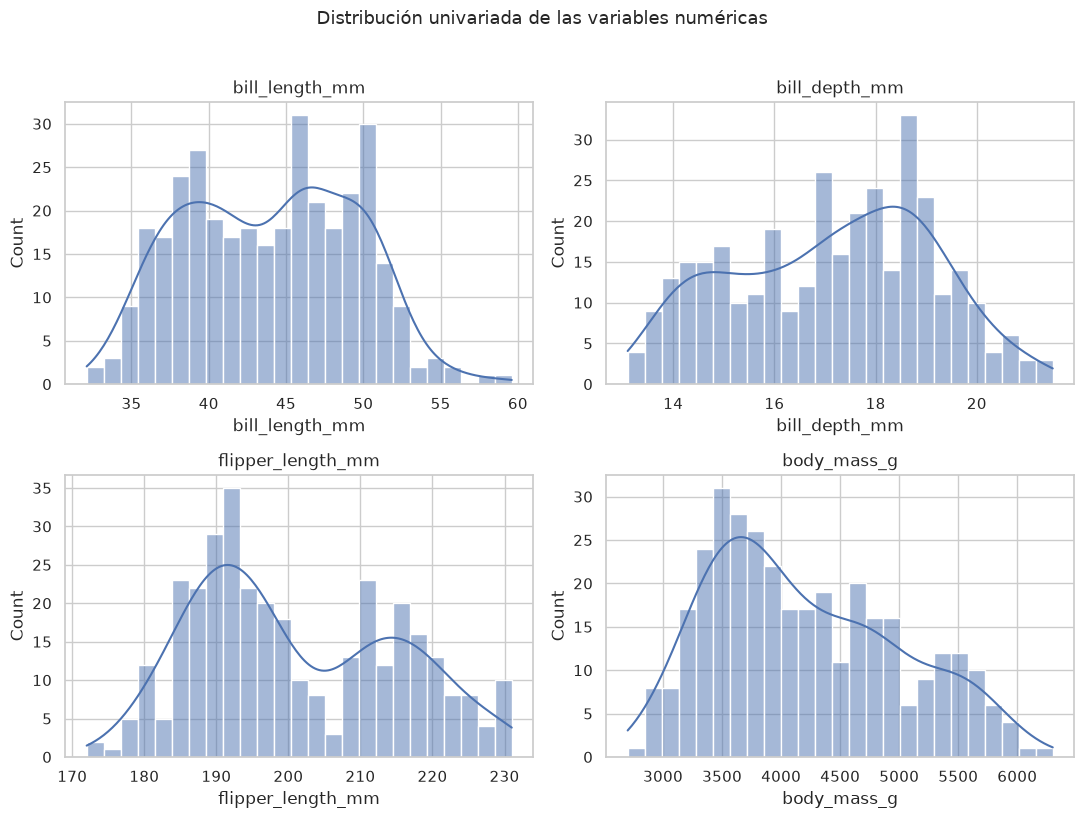

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(pinguinos[col], bins=25, kde=True, ax=ax, color="#4C72B0")
    ax.set_title(col)
fig.suptitle("Distribución univariada de las variables numéricas", y=1.02, fontsize=13)
fig.tight_layout()
plt.show()


**Lectura:** `bill_length_mm` y `body_mass_g` muestran una forma con más de una concentración
(bimodal / multimodal), señal de que mezclan especies con tamaños distintos. `bill_depth_mm` y
`flipper_length_mm` también insinúan dos grupos. Esto anticipa que la variable `species` va a ser
un fuerte factor explicativo de estas distribuciones (se retoma en los Ejercicios 2 y 3).


### 1.5 Boxplots — identificación de valores atípicos

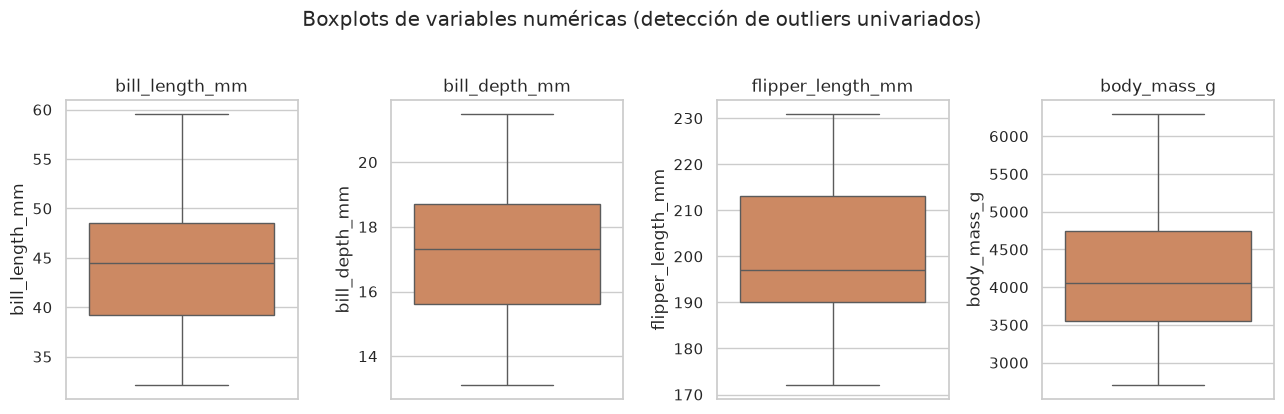

In [8]:
fig, axes = plt.subplots(1, 4, figsize=(13, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=pinguinos[col], ax=ax, color="#DD8452")
    ax.set_title(col)
fig.suptitle("Boxplots de variables numéricas (detección de outliers univariados)", y=1.03)
fig.tight_layout()
plt.show()


In [9]:
def outliers_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return serie[(serie < lo) | (serie > hi)]

for col in num_cols:
    out = outliers_iqr(pinguinos[col])
    print(f"{col}: {len(out)} posibles outliers (criterio 1.5*IQR)")


bill_length_mm: 0 posibles outliers (criterio 1.5*IQR)
bill_depth_mm: 0 posibles outliers (criterio 1.5*IQR)
flipper_length_mm: 0 posibles outliers (criterio 1.5*IQR)
body_mass_g: 0 posibles outliers (criterio 1.5*IQR)


**Lectura:** ninguna variable numérica presenta una cantidad relevante de outliers según el
criterio de 1.5·IQR — resultado esperable dada la curtosis negativa/cercana a 0 observada antes.
El dataset no muestra errores de carga evidentes ni valores extremos que requieran tratamiento
especial.


### 1.6 Distribución de variables categóricas

In [10]:
for col in cat_cols:
    print(f"--- {col} ---")
    print(datos_penguins[col].value_counts(dropna=False))
    print()


--- species ---
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

--- island ---
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

--- sex ---
sex
Male      168
Female    165
NaN        11
Name: count, dtype: int64



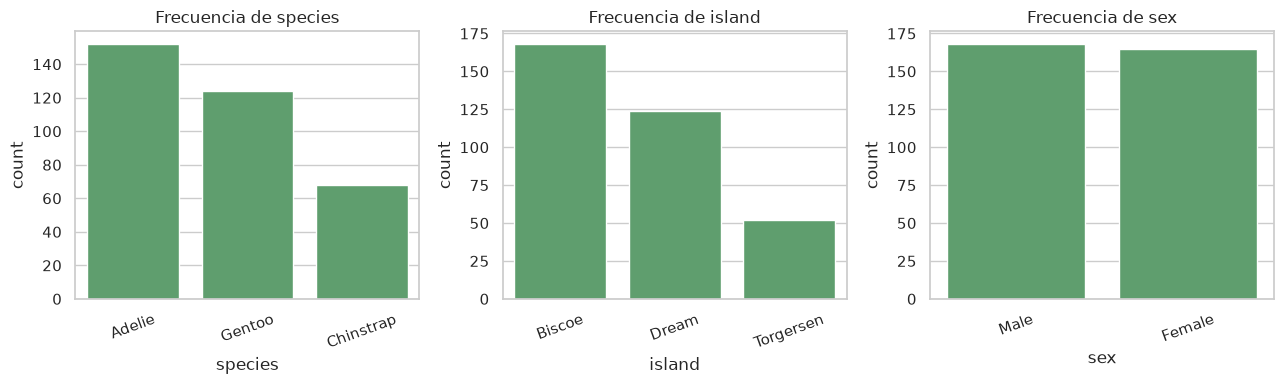

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, col in zip(axes, cat_cols):
    orden = datos_penguins[col].value_counts().index
    sns.countplot(x=datos_penguins[col], order=orden, ax=ax, color="#55A868")
    ax.set_title(f"Frecuencia de {col}")
    ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
plt.show()


**Lectura:** `species` está moderadamente desbalanceada (Adelie es la más numerosa, Chinstrap la
menos), lo mismo que `island` (Biscoe concentra la mayoría de los registros, en gran parte por ser
la única isla donde habita Gentoo). `sex` está prácticamente balanceada entre machos y hembras,
salvo los 11 valores faltantes ya señalados.

### Reporte univariado — síntesis
- Dataset con 344 observaciones, 4 variables numéricas y 3 categóricas; pocos valores faltantes,
  concentrados en 2 filas totalmente incompletas y 11 sin `sex`.
- Las variables numéricas son aproximadamente simétricas y platicúrticas, sin outliers relevantes.
- Varias variables numéricas muestran forma bi/multimodal, lo que sugiere que la especie es un
  factor de mezcla subyacente — hipótesis a explorar en el análisis bivariado y multivariado.
- Las variables categóricas están desbalanceadas en `species` e `island` (ligado a que Gentoo solo
  habita Biscoe), y balanceadas en `sex`.


## Ejercicio 2: Análisis Bivariado — Correlaciones y Asociaciones

### 2.1 Matriz de correlación y heatmap


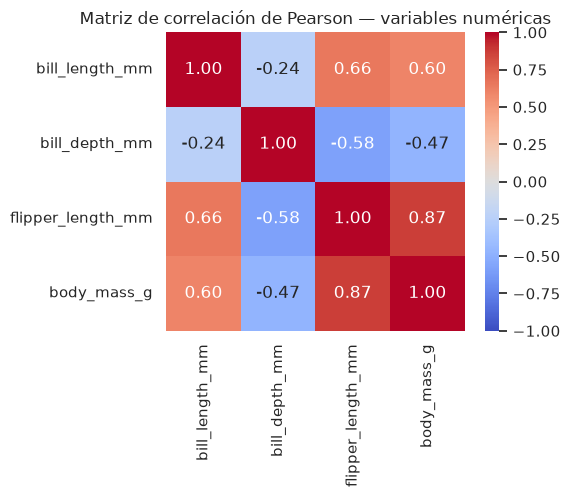

In [12]:
corr = pinguinos[num_cols].corr()
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, square=True)
plt.title("Matriz de correlación de Pearson — variables numéricas")
plt.tight_layout()
plt.show()


**Lectura:** `flipper_length_mm` y `body_mass_g` están fuertemente correlacionadas (r ≈ 0.87):
pingüinos con aletas más largas tienden a pesar más, lo cual es biológicamente esperable (aves de
mayor porte). `bill_depth_mm` correlaciona negativamente con las demás variables — se revisará si
es una correlación espuria en 2.4, ya que puede estar mezclando especies con formas de pico
distintas (paradoja de Simpson).


### 2.2 Scatter plots con línea de tendencia para las relaciones más significativas

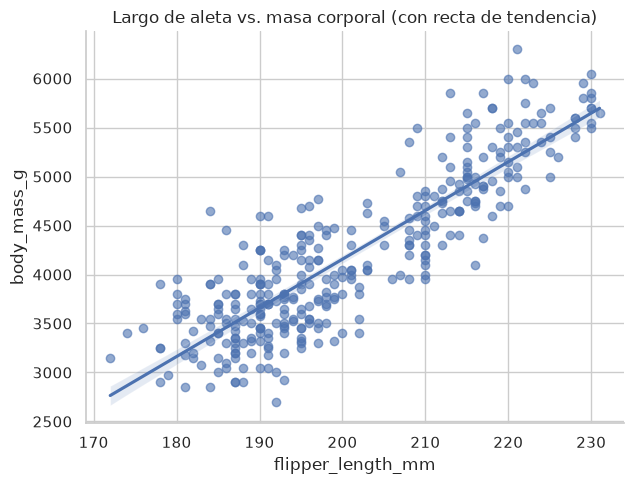

In [13]:
sns.lmplot(data=pinguinos, x="flipper_length_mm", y="body_mass_g",
           height=5, aspect=1.3, scatter_kws={"alpha": 0.6})
plt.title("Largo de aleta vs. masa corporal (con recta de tendencia)")
plt.tight_layout()
plt.show()


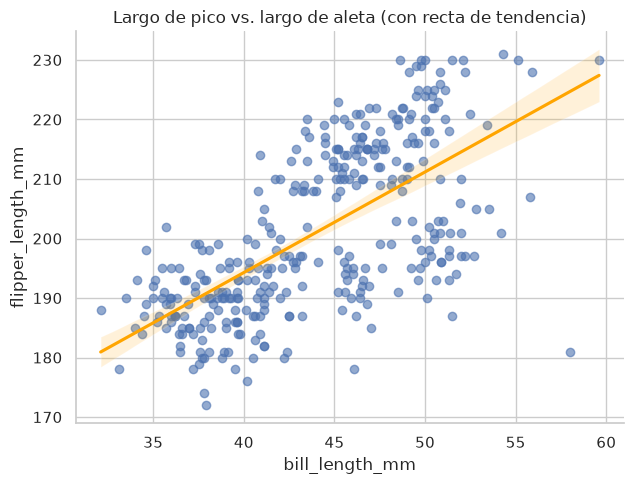

In [14]:
sns.lmplot(data=pinguinos, x="bill_length_mm", y="flipper_length_mm",
           height=5, aspect=1.3, scatter_kws={"alpha": 0.6}, line_kws={"color": "orange"})
plt.title("Largo de pico vs. largo de aleta (con recta de tendencia)")
plt.tight_layout()
plt.show()


### 2.3 Significancia estadística de las asociaciones (Pearson y Spearman)

In [15]:
from itertools import combinations

filas = []
for a, b in combinations(num_cols, 2):
    r_p, p_p = stats.pearsonr(pinguinos[a], pinguinos[b])
    r_s, p_s = stats.spearmanr(pinguinos[a], pinguinos[b])
    filas.append({
        "var_1": a, "var_2": b,
        "pearson_r": round(r_p, 3), "pearson_p": p_p,
        "spearman_rho": round(r_s, 3), "spearman_p": p_s,
    })
tabla_corr = pd.DataFrame(filas)
tabla_corr


,var_1,var_2,pearson_r,pearson_p,spearman_rho,spearman_p
0,bill_length_mm,bill_depth_mm,-0.235,1.119662e-05,-0.222,3.511540e-05
1,bill_length_mm,flipper_length_mm,0.656,1.743974e-43,0.673,2.066936e-46
2,bill_length_mm,body_mass_g,0.595,3.808283e-34,0.584,1.251881e-32
3,bill_depth_mm,flipper_length_mm,-0.584,1.232734e-32,-0.523,1.961166e-25
4,bill_depth_mm,body_mass_g,-0.472,2.276941e-20,-0.432,5.187825e-17
5,flipper_length_mm,body_mass_g,0.871,4.370681e-107,0.840,2.763219e-92


**Lectura:** todos los pares tienen p-valores extremadamente bajos (<< 0.05), es decir, las
asociaciones observadas son estadísticamente significativas y no atribuibles al azar dado el tamaño
de muestra (n≈342). Pearson y Spearman arrojan valores similares en magnitud y signo para todos los
pares, lo que indica que las relaciones son aproximadamente lineales (no hay evidencia de relaciones
monótonas fuertemente no lineales que Pearson esté subestimando).


### 2.4 Correlaciones espurias — el caso de `bill_depth_mm`

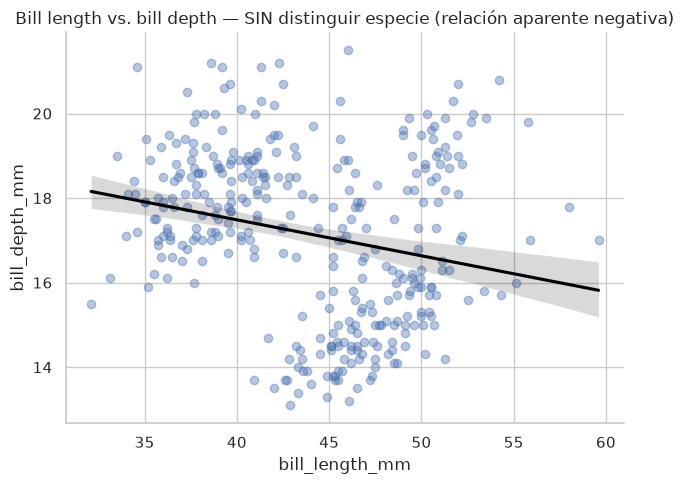

In [16]:
sns.lmplot(data=pinguinos, x="bill_length_mm", y="bill_depth_mm",
           height=5, aspect=1.3, scatter_kws={"alpha": 0.4}, line_kws={"color": "black"})
plt.title("Bill length vs. bill depth — SIN distinguir especie (relación aparente negativa)")
plt.tight_layout()
plt.show()


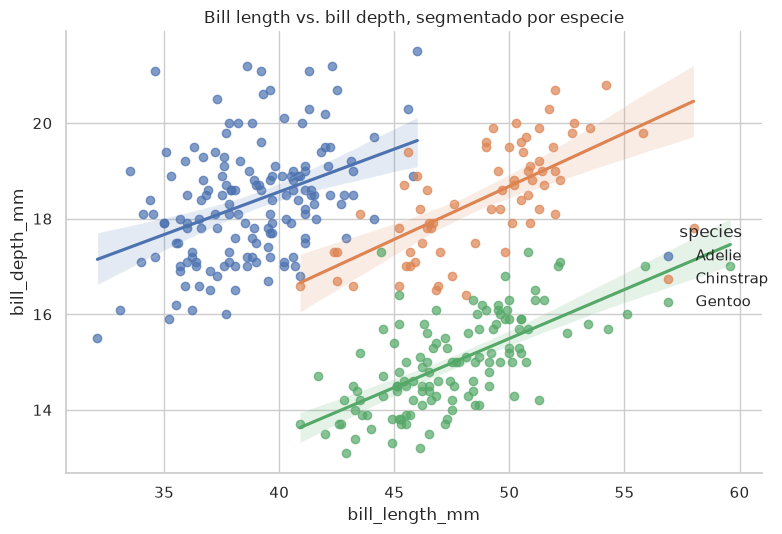

In [17]:
sns.lmplot(data=pinguinos, x="bill_length_mm", y="bill_depth_mm", hue="species",
           height=5.5, aspect=1.2, scatter_kws={"alpha": 0.7})
plt.title("Bill length vs. bill depth, segmentado por especie")
plt.tight_layout()
plt.show()


In [18]:
print("Correlacion global (sin segmentar):", round(pinguinos["bill_length_mm"].corr(pinguinos["bill_depth_mm"]), 3))
for esp, sub in pinguinos.groupby("species", observed=True):
    r = sub["bill_length_mm"].corr(sub["bill_depth_mm"])
    print(f"Correlacion dentro de {esp}: {r:.3f}")


Correlacion global (sin segmentar): -0.235
Correlacion dentro de Adelie: 0.391
Correlacion dentro de Chinstrap: 0.654
Correlacion dentro de Gentoo: 0.643


**Es la paradoja de Simpson en acción:** sin distinguir especie, `bill_length_mm` y `bill_depth_mm`
muestran correlación global negativa (r ≈ -0.23). Pero al segmentar por especie, la correlación
**dentro** de cada especie es positiva. Esto confirma que la correlación negativa global es
**espuria**: no refleja una relación biológica real entre largo y profundidad del pico, sino un
artefacto de que las tres especies ocupan regiones distintas del plano (Gentoo tiene picos largos y
poco profundos; Adelie y Chinstrap, picos más cortos y profundos). `species` es la variable de
confusión (*confounder*) que explica el cambio de signo.


### 2.5 Tablas de contingencia entre variables categóricas

In [19]:
tabla_especie_isla = pd.crosstab(datos_penguins["species"], datos_penguins["island"])
tabla_especie_isla


island,Biscoe,Dream,Torgersen
species,,,
Adelie,44,56,52
Chinstrap,0,68,0
Gentoo,124,0,0


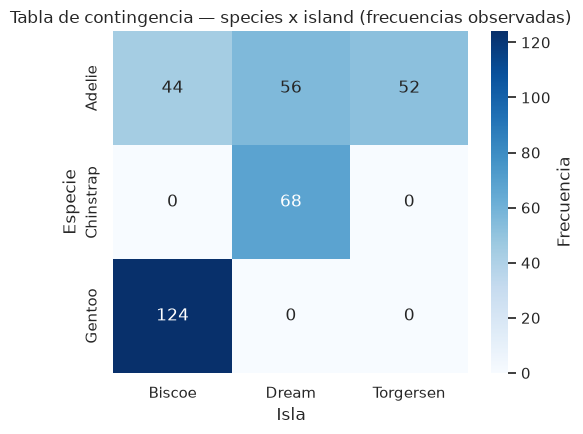

In [20]:
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(tabla_especie_isla, annot=True, fmt="d", cmap="Blues", cbar_kws={"label": "Frecuencia"})
plt.title("Tabla de contingencia — species x island (frecuencias observadas)")
plt.ylabel("Especie")
plt.xlabel("Isla")
plt.tight_layout()
plt.show()


In [21]:
tabla_especie_sexo = pd.crosstab(datos_penguins["species"], datos_penguins["sex"])
tabla_especie_sexo


sex,Female,Male
species,,
Adelie,73,73
Chinstrap,34,34
Gentoo,58,61


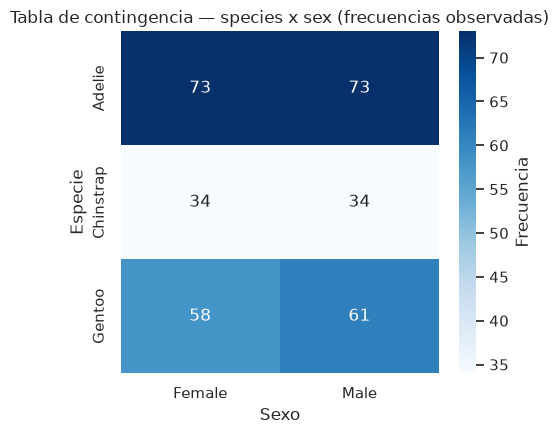

In [22]:
plt.figure(figsize=(5, 4.5))
sns.heatmap(tabla_especie_sexo, annot=True, fmt="d", cmap="Blues", cbar_kws={"label": "Frecuencia"})
plt.title("Tabla de contingencia — species x sex (frecuencias observadas)")
plt.ylabel("Especie")
plt.xlabel("Sexo")
plt.tight_layout()
plt.show()


**Lectura:** el heatmap de `species x island` muestra un patrón diagonal-disperso muy marcado —
Chinstrap y Gentoo aparecen concentrados en una única isla cada una (Dream y Biscoe
respectivamente), mientras Adelie es la única especie presente en las tres. Ese contraste de color
tan nítido anticipa visualmente la fuerte asociación que confirma el test chi-cuadrado a
continuación. El heatmap de `species x sex`, en cambio, muestra celdas de intensidad casi uniforme
entre Male y Female dentro de cada especie, sugiriendo ausencia de asociación — también se
confirma numéricamente más abajo.


### 2.6 Test de independencia chi-cuadrado

In [23]:
chi2, p, gl, esperado = stats.chi2_contingency(tabla_especie_isla)
print(f"species x island -> chi2 = {chi2:.2f}, gl = {gl}, p-valor = {p:.3e}")
print("Interpretacion: p << 0.05 -> se rechaza independencia: la especie y la isla estan asociadas")
print("(coherente con que Chinstrap y Gentoo solo aparecen en una isla cada una).")


species x island -> chi2 = 299.55, gl = 4, p-valor = 1.355e-63
Interpretacion: p << 0.05 -> se rechaza independencia: la especie y la isla estan asociadas
(coherente con que Chinstrap y Gentoo solo aparecen en una isla cada una).


In [24]:
chi2b, pb, glb, esperadob = stats.chi2_contingency(tabla_especie_sexo)
print(f"species x sex -> chi2 = {chi2b:.2f}, gl = {glb}, p-valor = {pb:.3f}")
print("Interpretacion: p > 0.05 -> no hay evidencia de asociacion entre especie y sexo")
print("(el sexo esta aproximadamente balanceado dentro de cada especie).")


species x sex -> chi2 = 0.05, gl = 2, p-valor = 0.976
Interpretacion: p > 0.05 -> no hay evidencia de asociacion entre especie y sexo
(el sexo esta aproximadamente balanceado dentro de cada especie).


### Reporte bivariado — síntesis
- `flipper_length_mm` y `body_mass_g` son las variables numéricas más asociadas linealmente
  (r ≈ 0.87, p < 0.001): buenas candidatas como predictoras conjuntas de tamaño corporal.
- La correlación negativa global entre `bill_length_mm` y `bill_depth_mm` es **espuria**: se explica
  por la mezcla de especies (paradoja de Simpson); dentro de cada especie la relación es positiva.
- `species` está fuertemente asociada con `island` (χ² significativo) por restricciones geográficas
  de habitat, pero no con `sex` (sin evidencia de asociación).
- En conjunto, `species` emerge como variable de confusión clave: cualquier análisis bivariado entre
  variables morfológicas debería reportarse también segmentado por especie.


## Ejercicio 3: Análisis Multivariado y Visualización Avanzada

### 3.1 Matriz de dispersión (pairplot) coloreada por especie


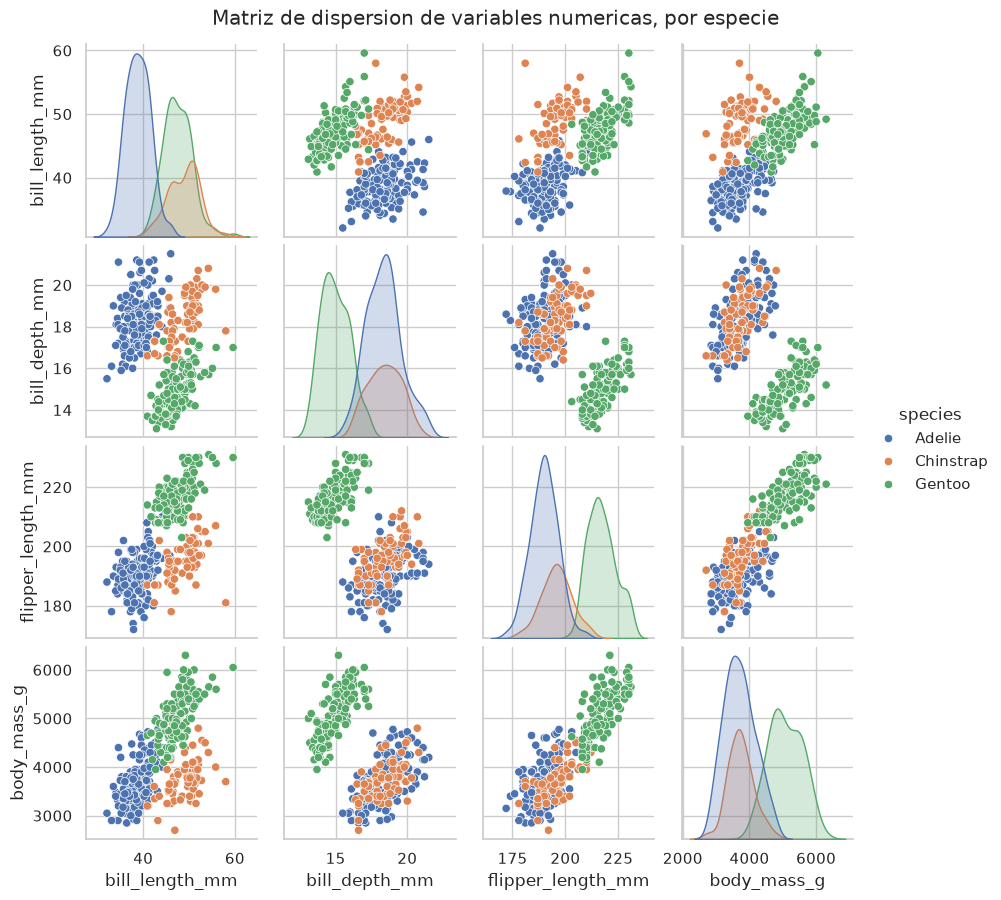

In [25]:
sns.pairplot(pinguinos, vars=num_cols, hue="species", diag_kind="kde", height=2.2)
plt.suptitle("Matriz de dispersion de variables numericas, por especie", y=1.02)
plt.show()


**Lectura:** el pairplot muestra que, combinando cualquier par de variables morfológicas, las tres
especies forman nubes de puntos bastante separables — en particular `flipper_length_mm` y
`body_mass_g` (Gentoo se distingue con claridad) y `bill_length_mm` combinada con casi cualquier
otra variable (separa bien a Adelie de las otras dos). Esto anticipa la alta separabilidad de clases
mencionada en el Ejercicio 5.


### 3.2 Coordenadas paralelas

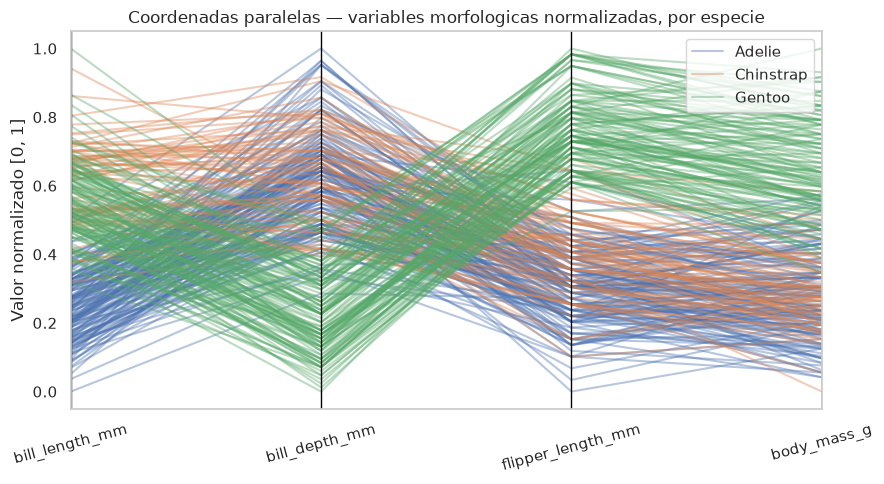

In [26]:
normalizado = pinguinos[num_cols].apply(lambda c: (c - c.min()) / (c.max() - c.min()))
normalizado["species"] = pinguinos["species"].to_numpy()

plt.figure(figsize=(9, 5))
parallel_coordinates(normalizado, "species", color=sns.color_palette("deep", 3), alpha=0.4)
plt.title("Coordenadas paralelas — variables morfologicas normalizadas, por especie")
plt.ylabel("Valor normalizado [0, 1]")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


**Lectura:** se distinguen "perfiles" de línea claramente distintos por especie: Gentoo se mantiene
alto en `flipper_length_mm` y `body_mass_g` pero bajo en `bill_depth_mm`; Chinstrap tiende a valores
altos de `bill_length_mm`; Adelie se mantiene consistentemente en la zona baja de casi todas las
variables salvo `bill_depth_mm`. El cruce de líneas entre `bill_depth_mm` y `flipper_length_mm`
visualiza la correlación negativa entre ambas comentada en el Ejercicio 2.


### 3.3 Heatmaps de correlación segmentados por especie

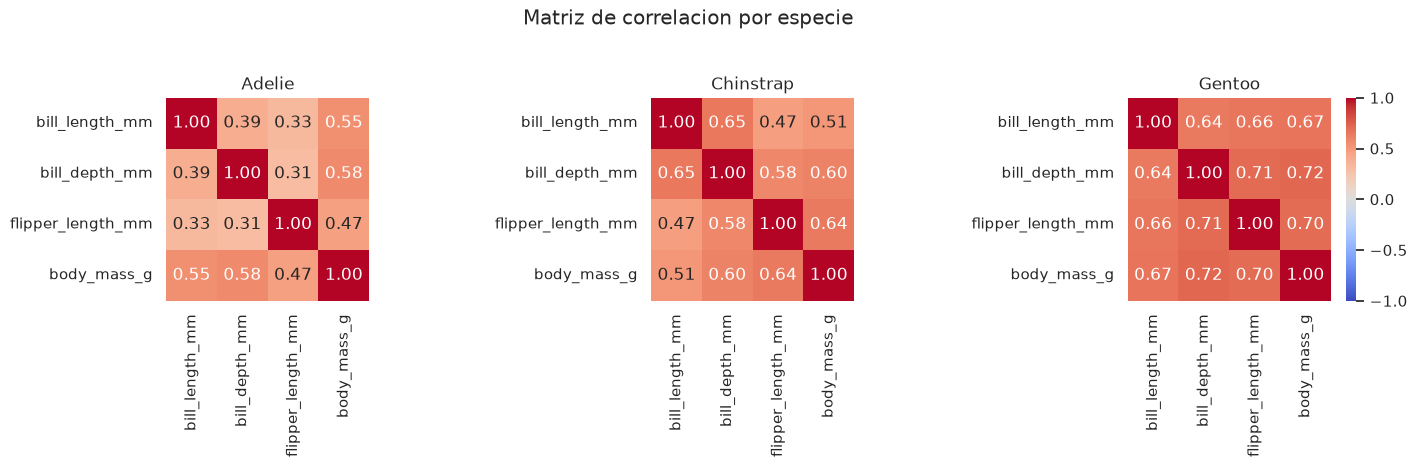

In [27]:
especies = pinguinos["species"].unique()
fig, axes = plt.subplots(1, len(especies), figsize=(15, 4.5))
for ax, especie in zip(axes, especies):
    sub_corr = pinguinos.loc[pinguinos["species"] == especie, num_cols].corr()
    sns.heatmap(sub_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1,
                ax=ax, cbar=(especie == especies[-1]), square=True)
    ax.set_title(especie)
fig.suptitle("Matriz de correlacion por especie", y=1.03)
fig.tight_layout()
plt.show()


**Lectura:** al segmentar por especie, `bill_length_mm` y `bill_depth_mm` correlacionan
**positivamente** en las tres especies (confirmando la paradoja de Simpson detectada antes). La
intensidad de las correlaciones también varía entre especies: por ejemplo, `flipper_length_mm` y
`body_mass_g` están fuertemente asociadas en las tres, pero con distinta magnitud, lo que sugiere que
el patrón de crecimiento morfológico no es idéntico entre especies.


### 3.4 Agrupamiento jerárquico de variables por correlación (dendrograma)

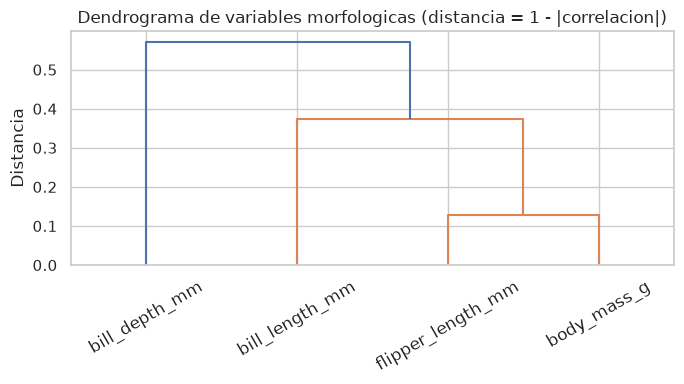

In [28]:
corr_abs_dist = 1 - pinguinos[num_cols].corr().abs()
enlace = linkage(corr_abs_dist.values[np.triu_indices(len(num_cols), k=1)], method="average")

plt.figure(figsize=(7, 4))
dendrogram(enlace, labels=num_cols, leaf_rotation=30)
plt.title("Dendrograma de variables morfologicas (distancia = 1 - |correlacion|)")
plt.ylabel("Distancia")
plt.tight_layout()
plt.show()


**Lectura:** `flipper_length_mm` y `body_mass_g` son las variables que primero se agrupan (menor
distancia = mayor correlación absoluta entre ellas), formando un cluster de "tamaño corporal
general". `bill_depth_mm` se une más tarde al resto, comportándose como la variable más
independiente/informativa del conjunto — buena candidata a aportar información no redundante en un
modelo.


### 3.5 Gráficos de radar (spider plots) — perfil morfológico promedio por especie

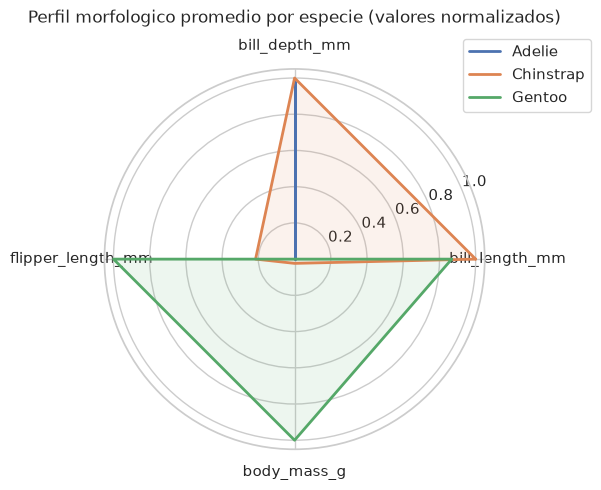

In [29]:
promedios = pinguinos.groupby("species", observed=True)[num_cols].mean()
promedios_norm = (promedios - promedios.min()) / (promedios.max() - promedios.min())

categorias = list(promedios_norm.columns)
n_cat = len(categorias)
angulos = np.linspace(0, 2 * np.pi, n_cat, endpoint=False).tolist()
angulos += angulos[:1]

fig, ax = plt.subplots(figsize=(6.5, 6.5), subplot_kw={"projection": "polar"})
for especie in promedios_norm.index:
    valores = promedios_norm.loc[especie].tolist()
    valores += valores[:1]
    ax.plot(angulos, valores, label=especie, linewidth=2)
    ax.fill(angulos, valores, alpha=0.1)

ax.set_xticks(angulos[:-1])
ax.set_xticklabels(categorias)
ax.set_title("Perfil morfologico promedio por especie (valores normalizados)", y=1.1)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()


**Lectura:** el spider plot resume visualmente lo detectado en las coordenadas paralelas: Gentoo
domina en `flipper_length_mm` y `body_mass_g` pero es mínimo en `bill_depth_mm`; Chinstrap se
destaca en `bill_length_mm`; Adelie tiene el perfil más "compacto" (valores intermedios/bajos salvo
en `bill_depth_mm`, donde es el más alto). Los tres polígonos tienen formas claramente distintas, lo
que confirma visualmente la alta separabilidad de especies mencionada en la consigna del Ejercicio 5.

### Reporte multivariado — síntesis
- Las tres especies ocupan regiones bien diferenciadas en el espacio morfológico multivariado
  (pairplot, coordenadas paralelas y radar coinciden en esto).
- `flipper_length_mm` y `body_mass_g` capturan esencialmente la misma dimensión de "tamaño corporal"
  (se agrupan juntas en el dendrograma); `bill_depth_mm` aporta información más independiente.
- El signo de la correlación entre variables de pico depende de si se controla por especie —
  refuerza que `species` es la variable estructural que organiza toda la variabilidad morfológica.


## Ejercicio 4: Muestreo y Reducción Dimensional

### 4.1 Estrategias de muestreo: aleatorio simple vs. estratificado


In [30]:
print("Proporciones de especie en el dataset completo:")
print(pinguinos["species"].value_counts(normalize=True).round(3))


Proporciones de especie en el dataset completo:
species
Adelie       0.442
Gentoo       0.360
Chinstrap    0.199
Name: proportion, dtype: float64


In [31]:
# Muestreo aleatorio simple (20%)
muestra_aleatoria = pinguinos.sample(frac=0.2, random_state=RANDOM_STATE)

# Muestreo estratificado balanceado: mismo n de cada especie (groupby + sample)
n_min = pinguinos["species"].value_counts().min()
muestra_estratificada_balanceada = (
    pinguinos.groupby("species", observed=True)
    .sample(n=n_min, random_state=RANDOM_STATE)
)

# Muestreo estratificado manteniendo proporciones originales (train_test_split con stratify)
muestra_estratificada_proporcional, _ = train_test_split(
    pinguinos, train_size=0.2, stratify=pinguinos["species"], random_state=RANDOM_STATE
)

resumen_muestreo = pd.DataFrame({
    "completo": pinguinos["species"].value_counts(normalize=True),
    "aleatorio_simple": muestra_aleatoria["species"].value_counts(normalize=True),
    "estratificado_balanceado": muestra_estratificada_balanceada["species"].value_counts(normalize=True),
    "estratificado_proporcional": muestra_estratificada_proporcional["species"].value_counts(normalize=True),
}).round(3)
resumen_muestreo


,completo,aleatorio_simple,estratificado_balanceado,estratificado_proporcional
species,,,,
Adelie,0.442,0.500,0.333,0.441
Chinstrap,0.199,0.176,0.333,0.206
Gentoo,0.360,0.324,0.333,0.353


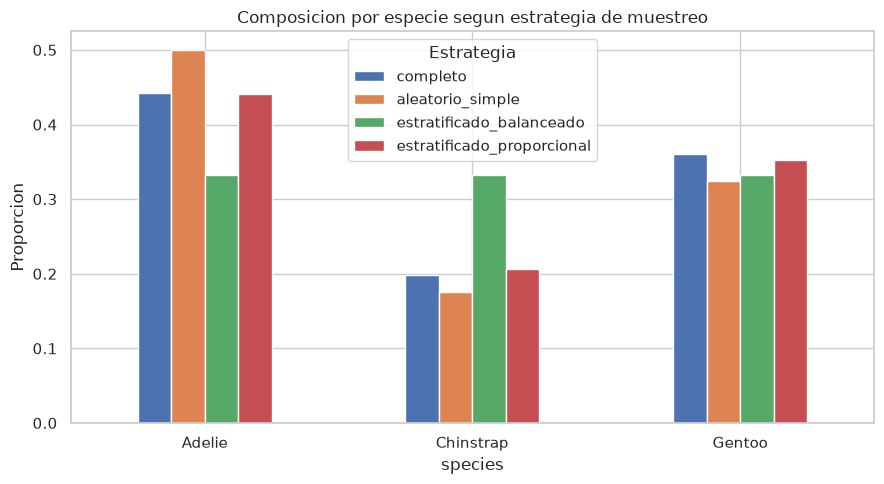

In [32]:
resumen_muestreo.plot(kind="bar", figsize=(9, 5))
plt.title("Composicion por especie segun estrategia de muestreo")
plt.ylabel("Proporcion")
plt.xticks(rotation=0)
plt.legend(title="Estrategia")
plt.tight_layout()
plt.show()


**Lectura:** el muestreo aleatorio simple aproxima razonablemente las proporciones originales, pero
con algo de variación esperable por azar. El muestreo estratificado proporcional (`train_test_split`
con `stratify`) reproduce casi exactamente las proporciones del dataset completo — es la opción
recomendada cuando el objetivo es preservar la representatividad. El muestreo estratificado
balanceado, en cambio, iguala deliberadamente el tamaño de cada especie (útil si se quiere evitar
que una especie minoritaria quede subrepresentada en un análisis o modelo posterior, a costa de no
reflejar la proporción real de la población).


### 4.2 Análisis de Componentes Principales (PCA)

In [33]:
X = pinguinos[num_cols].values
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

pca_completo = PCA(random_state=RANDOM_STATE).fit(X_std)
varianza_acumulada = np.cumsum(pca_completo.explained_variance_ratio_)

n_componentes_95 = int(np.argmax(varianza_acumulada >= 0.95) + 1)
print("Varianza explicada por componente:", pca_completo.explained_variance_ratio_.round(3))
print("Varianza acumulada:", varianza_acumulada.round(3))
print(f"Componentes necesarios para retener >= 95% de la varianza: {n_componentes_95}")


Varianza explicada por componente: [0.688 0.193 0.091 0.027]
Varianza acumulada: [0.688 0.882 0.973 1.   ]
Componentes necesarios para retener >= 95% de la varianza: 3


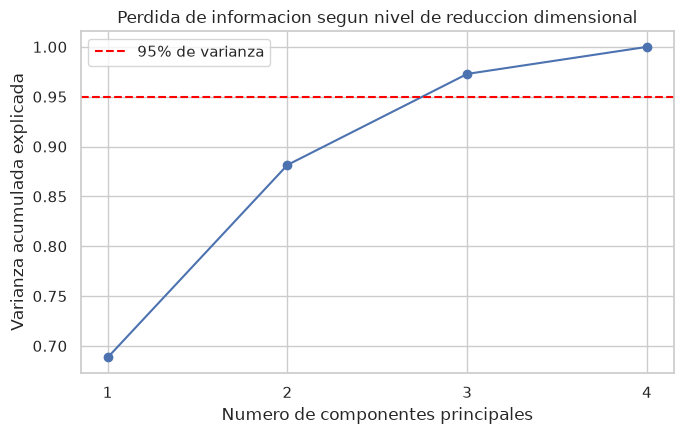

In [34]:
plt.figure(figsize=(7, 4.5))
plt.plot(range(1, len(varianza_acumulada) + 1), varianza_acumulada, marker="o")
plt.axhline(0.95, color="red", linestyle="--", label="95% de varianza")
plt.xlabel("Numero de componentes principales")
plt.ylabel("Varianza acumulada explicada")
plt.title("Perdida de informacion segun nivel de reduccion dimensional")
plt.xticks(range(1, len(varianza_acumulada) + 1))
plt.legend()
plt.tight_layout()
plt.show()


**Lectura:** con 4 variables numéricas de partida, se necesitan las primeras componentes principales
indicadas arriba para retener al menos el 95% de la varianza — es decir, la reducción dimensional
posible es limitada porque las variables ya son relativamente pocas y no totalmente redundantes
(coherente con el dendrograma del Ejercicio 3, donde solo dos variables estaban fuertemente
correlacionadas entre sí).


### 4.3 Visualización: datos originales (pairplot) vs. proyección PCA en 2D

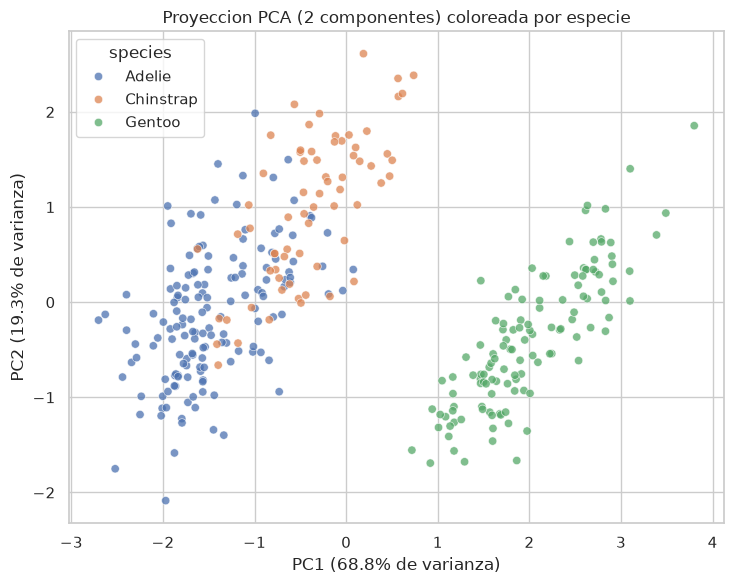

In [35]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
componentes_2d = pca_2d.fit_transform(X_std)

pca_df = pd.DataFrame(componentes_2d, columns=["PC1", "PC2"])
pca_df["species"] = pinguinos["species"].to_numpy()

plt.figure(figsize=(7.5, 6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="species", alpha=0.75)
var1, var2 = pca_2d.explained_variance_ratio_ * 100
plt.xlabel(f"PC1 ({var1:.1f}% de varianza)")
plt.ylabel(f"PC2 ({var2:.1f}% de varianza)")
plt.title("Proyeccion PCA (2 componentes) coloreada por especie")
plt.tight_layout()
plt.show()


In [36]:
cargas = pd.DataFrame(pca_2d.components_.T, index=num_cols, columns=["PC1", "PC2"]).round(3)
cargas


,PC1,PC2
bill_length_mm,0.455,0.597
bill_depth_mm,-0.400,0.798
flipper_length_mm,0.576,0.002
body_mass_g,0.548,0.084


**Interpretación de las componentes:** PC1 concentra la mayor parte de la varianza y pondera con el
mismo signo a `flipper_length_mm`, `body_mass_g` y `bill_length_mm` (con `bill_depth_mm` en sentido
opuesto) — puede leerse como un eje general de "tamaño corporal / forma del pico" que por sí solo ya
separa razonablemente a Gentoo del resto. PC2 aporta un eje secundario que ayuda a separar Adelie de
Chinstrap. En conjunto, dos componentes alcanzan para visualizar una separación de especies
comparable a la que se aprecia recorriendo el pairplot completo de 4 variables — es la ventaja
práctica de la reducción dimensional: comprimir la información relevante en menos ejes sin perder la
estructura de clases.


### 4.4 Reducción no lineal: t-SNE vs. PCA

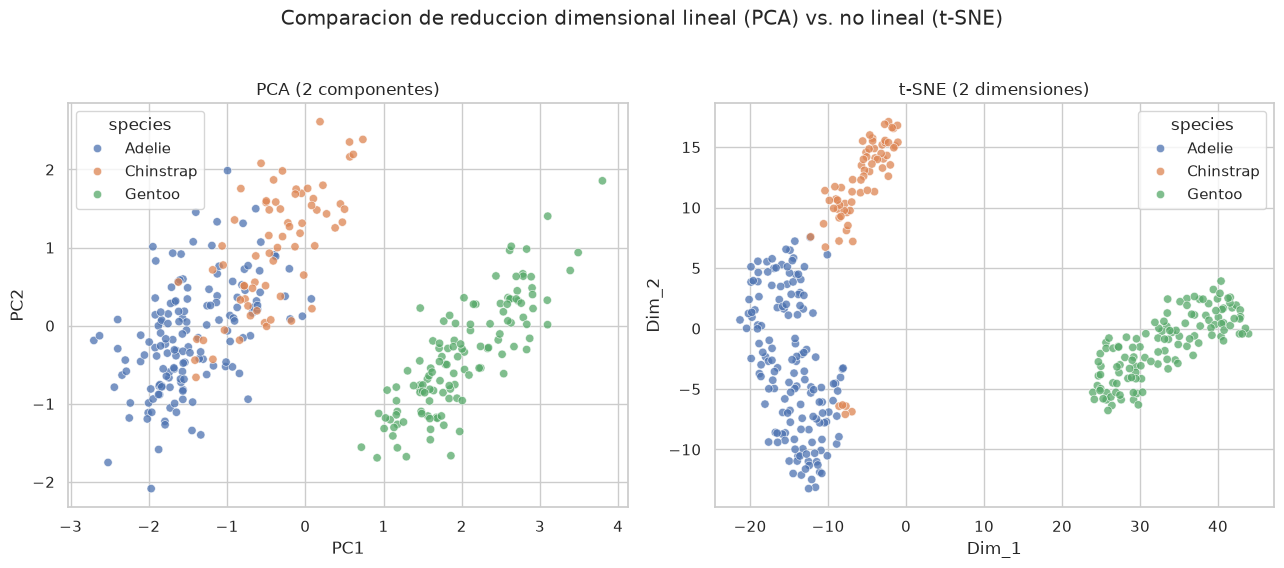

In [37]:
tsne = TSNE(n_components=2, perplexity=30, random_state=RANDOM_STATE, init="pca")
componentes_tsne = tsne.fit_transform(X_std)

tsne_df = pd.DataFrame(componentes_tsne, columns=["Dim_1", "Dim_2"])
tsne_df["species"] = pinguinos["species"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="species", alpha=0.75, ax=axes[0])
axes[0].set_title("PCA (2 componentes)")

sns.scatterplot(data=tsne_df, x="Dim_1", y="Dim_2", hue="species", alpha=0.75, ax=axes[1])
axes[1].set_title("t-SNE (2 dimensiones)")

fig.suptitle("Comparacion de reduccion dimensional lineal (PCA) vs. no lineal (t-SNE)", y=1.03)
fig.tight_layout()
plt.show()


**Lectura:** ambas técnicas separan visualmente bien a las tres especies, confirmando la alta
separabilidad de clases del dataset. PCA produce una separación algo más "difusa" en los bordes entre
Adelie y Chinstrap porque está restringido a combinaciones lineales de las variables originales.
t-SNE, al modelar similitudes locales de forma no lineal, suele generar clusters más compactos y
mejor delimitados — pero a costa de que las distancias entre clusters y la escala de los ejes ya no
tienen una interpretación directa (a diferencia de PCA, donde cada eje es una combinación lineal
interpretable de las variables originales, con varianza explicada conocida).

### Reporte de muestreo y reducción dimensional — síntesis
- El muestreo estratificado proporcional (`train_test_split` con `stratify`) es la estrategia más
  adecuada cuando se busca preservar fielmente la composición original de especies; el estratificado
  balanceado es preferible si se quiere garantizar representación mínima de la clase minoritaria.
- PCA logra retener la mayor parte de la varianza con pocas componentes y ofrece interpretabilidad
  directa de los ejes (cargas de cada variable), a costa de asumir relaciones lineales.
- t-SNE logra una separación visual de especies igual o más nítida que PCA, útil para inspección
  exploratoria, pero sacrifica interpretabilidad de los ejes y la noción de varianza explicada.
- Para este dataset, dado que ya tiene pocas variables (4 numéricas) y baja redundancia entre ellas,
  la reducción dimensional aporta sobre todo valor de **visualización** más que de compresión
  computacional — la estrategia más adecuada en la práctica es PCA a 2 componentes como resumen
  interpretable, complementado con t-SNE para confirmar visualmente la separabilidad.
